In [12]:
from utils import load_data, preprocess_funcs, plotting_funcs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
lower_jsons = r'C:\Users\samkr\OneDrive\Documents\GitHub\Reconstruction_code\reconstructions\data\PTs\lowers\json'
upper_jsons = r'C:\Users\samkr\OneDrive\Documents\GitHub\Reconstruction_code\reconstructions\data\PTs\uppers\json'

In [3]:
pt_uppers, aidtoreg, regtoaid, abvtoaid = load_data.load_neurons(upper_jsons)
pt_lowers, _, _, _ = load_data.load_neurons(lower_jsons)

21it [00:00, 49.27it/s]
9it [00:00, 33.55it/s]


In [4]:
upper1 = ['AA1633', 'AA0772', 'AA0726', 'AA0261', 'AA0245', 'AA0182', 'AA0122', 'AA0114']
upper2 = ['AA0181', 'AA0250', 'AA0583', 'AA0587', 'AA0617', 'AA0791', 'AA0794', 'AA0926', 'AA0927', 'AA1212', 'AA1221', 'AA1579', 'AA1625']
lower = ['AA0012', 'AA0114', 'AA0180', 'AA0182', 'AA0250', 'AA0788', 'AA0923', 'AA1190', 'AA1543']
upper1dict = {}
for name in upper1:
    upper1dict[name] = pt_uppers[name]

upper2dict = {}
for name in upper2:
    upper2dict[name] = pt_uppers[name]

lowerdict = {}
for name in lower:
    lowerdict[name] = pt_lowers[name]

In [14]:
abvtoaid['TH']

549

In [7]:
#pontine grey code is 931
upper1nodes_pg = preprocess_funcs.get_nodes_in_region(upper1dict, 931)
upper2nodes_pg = preprocess_funcs.get_nodes_in_region(upper2dict, 931)
lowernodes_pg = preprocess_funcs.get_nodes_in_region(lowerdict, 931)

In [19]:
upper1nodes_bg = preprocess_funcs.get_nodes_in_region(upper1dict, 1022) + preprocess_funcs.get_nodes_in_region(upper1dict, 672)
upper2nodes_bg = preprocess_funcs.get_nodes_in_region(upper2dict, 672) + preprocess_funcs.get_nodes_in_region(upper2dict, 1022)
print(len(upper2nodes_bg), len(upper1nodes_bg))

8026 5340


In [8]:

upper1sc_x = preprocess_funcs.get_coords(preprocess_funcs.get_nodes_in_region(upper1dict, 294), 'x')
upper1sc_y = preprocess_funcs.get_coords(preprocess_funcs.get_nodes_in_region(upper1dict, 294), 'y')
upper1sc_z = preprocess_funcs.get_coords(preprocess_funcs.get_nodes_in_region(upper1dict, 294), 'z')

upper2sc_x = preprocess_funcs.get_coords(preprocess_funcs.get_nodes_in_region(upper2dict, 294), 'x')
upper2sc_y = preprocess_funcs.get_coords(preprocess_funcs.get_nodes_in_region(upper2dict, 294), 'y')
upper2sc_z = preprocess_funcs.get_coords(preprocess_funcs.get_nodes_in_region(upper2dict, 294), 'z')

In [ ]:
print(len(upper1nodes_pg), len(upper2nodes_pg))

In [9]:
upper1pg_x = preprocess_funcs.get_coords(upper1nodes_pg, 'x')
upper1pg_y = preprocess_funcs.get_coords(upper1nodes_pg, 'y')
upper1pg_z = preprocess_funcs.get_coords(upper1nodes_pg, 'z')

upper2pg_x = preprocess_funcs.get_coords(upper2nodes_pg, 'x')
upper2pg_y = preprocess_funcs.get_coords(upper2nodes_pg, 'y')
upper2pg_z = preprocess_funcs.get_coords(upper2nodes_pg, 'z')

lowerpg_x = preprocess_funcs.get_coords(lowernodes_pg, 'x')
lowerpg_y = preprocess_funcs.get_coords(lowernodes_pg, 'y')
lowerpg_z = preprocess_funcs.get_coords(lowernodes_pg, 'z')

# allx = upper1pg_x + upper2pg_x
# ally = upper1pg_y + upper2pg_y
# allz = upper1pg_z + upper2pg_z

# xrange = (np.min(allx), np.max(allx))
# yrange = (np.min(ally), np.max(ally))
# zrange = (np.min(allz), np.max(allz))


In [ ]:
#hist with poly element on, think using a kde is better as it smooths and controls for different n between populations
fig, (xax, yax, zax) = plt.subplots(1, 3, figsize=(20,6))
fig.suptitle('PT distribution in pontine grey')
fig.supylabel('node count')
fig.supxlabel('allen CCF coordinates')

xax.set_xlabel('ML')
yax.set_xlabel('DV')
zax.set_xlabel('AP')

sns.histplot(data=upper1pg_x, color='blue', alpha=0.5, element='poly', ax=xax, fill=False)
sns.histplot(data=upper2pg_x, color='red', alpha=0.5, element='poly', ax=xax, fill=False)
sns.histplot(data=lowerpg_x, color='green', alpha=0.5, element='poly', ax=xax, fill=False)

sns.histplot(data=upper1pg_y, color='blue', alpha=0.5, element='poly', ax=yax, fill=False)
sns.histplot(data=upper2pg_y, color='red', alpha=0.5, element='poly', ax=yax, fill=False)
sns.histplot(data=lowerpg_y, color='green', alpha=0.5, element='poly', ax=yax, fill=False)

sns.histplot(data=upper1pg_z, color='blue', alpha=0.5, element='poly', ax=zax, fill=False)
sns.histplot(data=upper2pg_z, color='red', alpha=0.5, element='poly', ax=zax, fill=False)
sns.histplot(data=lowerpg_z, color='green', alpha=0.5, element='poly', ax=zax, fill=False)

lines = xax.get_lines()
lines[0].set_label('PT_upper 1')
lines[1].set_label('PT_upper 2')
lines[2].set_label('PT_lower')
fig.legend()

In [ ]:
fig, (xax, yax, zax) = plt.subplots(1, 3, figsize=(20,6))
fig.suptitle('PT distribution in pontine grey')
fig.supylabel('kernel density')
fig.supxlabel('allen CCF coordinates')

xax.set_xlabel('ML')
yax.set_xlabel('DV')
zax.set_xlabel('AP')

sns.kdeplot(data=upper1pg_x, color='blue', alpha=0.5, ax=xax)
sns.kdeplot(data=upper2pg_x, color='red', alpha=0.5, ax=xax)
sns.kdeplot(data=lowerpg_x, color='green', alpha=0.5, ax=xax)

sns.kdeplot(data=upper1pg_y, color='blue', alpha=0.5, ax=yax)
sns.kdeplot(data=upper2pg_y, color='red', alpha=0.5, ax=yax)
sns.kdeplot(data=lowerpg_y, color='green', alpha=0.5, ax=yax)

sns.kdeplot(data=upper1pg_z, color='blue', alpha=0.5, ax=zax)
sns.kdeplot(data=upper2pg_z, color='red', alpha=0.5, ax=zax)
sns.kdeplot(data=lowerpg_z, color='green', alpha=0.5, ax=zax)

lines = xax.get_lines()
lines[0].set_label('PT_upper 1')
lines[1].set_label('PT_upper 2')
lines[2].set_label('PT_lower')
fig.legend()

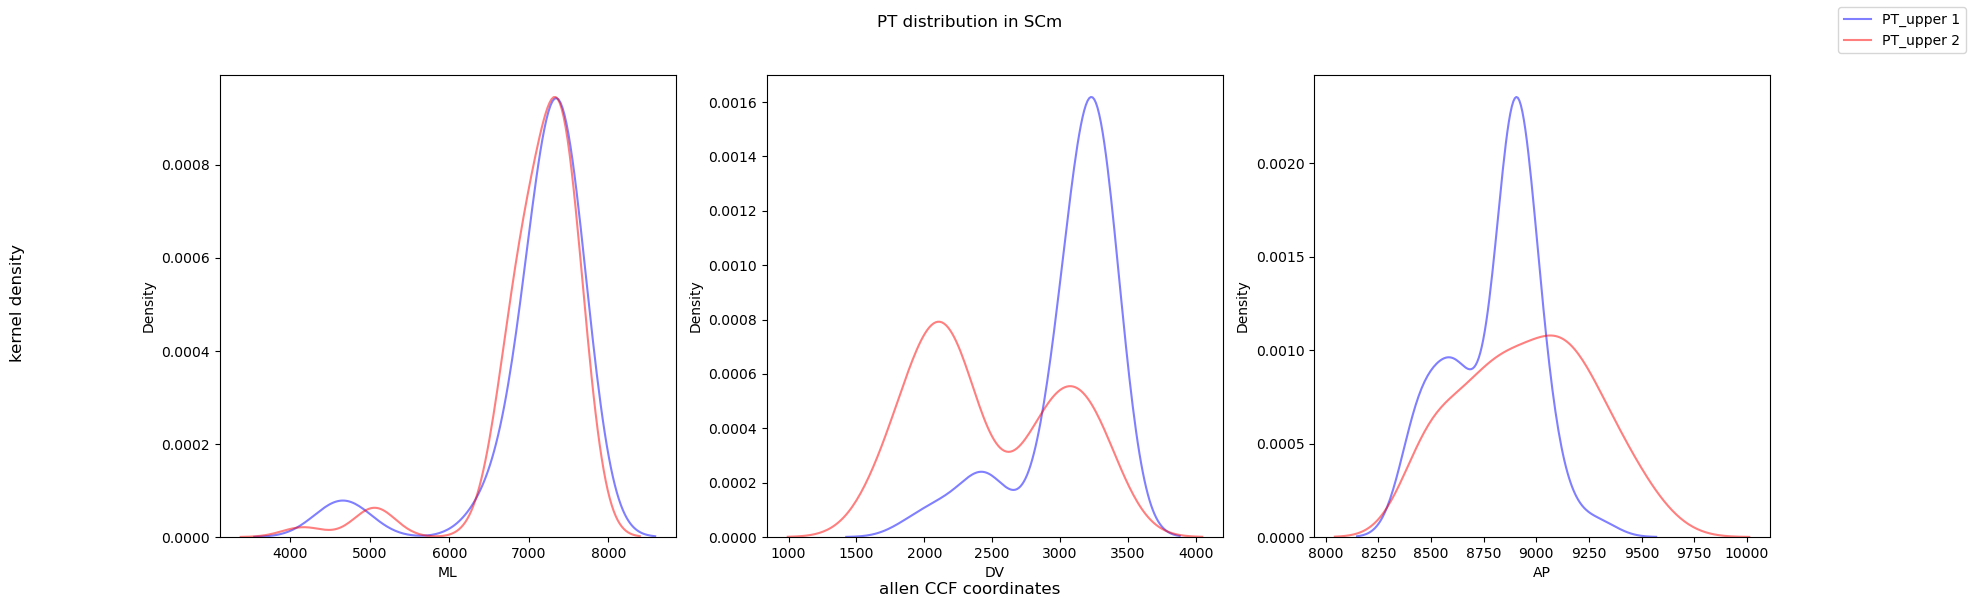

In [11]:
fig, (xax, yax, zax) = plt.subplots(1, 3, figsize=(20,6))
fig.suptitle('PT distribution in SCm')
fig.supylabel('kernel density')
fig.supxlabel('allen CCF coordinates')

xax.set_xlabel('ML')
yax.set_xlabel('DV')
zax.set_xlabel('AP')

sns.kdeplot(data=upper1sc_x, color='blue', alpha=0.5, ax=xax)
sns.kdeplot(data=upper2sc_x, color='red', alpha=0.5, ax=xax)

sns.kdeplot(data=upper1sc_y, color='blue', alpha=0.5, ax=yax)
sns.kdeplot(data=upper2sc_y, color='red', alpha=0.5, ax=yax)

sns.kdeplot(data=upper1sc_z, color='blue', alpha=0.5, ax=zax)
sns.kdeplot(data=upper2sc_z, color='red', alpha=0.5, ax=zax)

lines = xax.get_lines()
lines[0].set_label('PT_upper 1')
lines[1].set_label('PT_upper 2')
fig.legend()

In [ ]:
plotting_funcs.plot_axon_dist_in_region(upper1nodes_bg, upper2nodes_bg, region='Caudoputamen and Globus Pallidus')